  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached giotto_tda-0.6.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.7 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached giotto_ph-0.2.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached pyflagser-0.4.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.0 kB)
  Using cached igraph-1.0.0-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (4.4 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metadata (23 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86

=== 1. CONSTRUCT PHARMACOLOGICAL FEATURE SPACE ===
Pharmacological Feature Space constructed: 96 dimensions.
Computing Euclidean Distance Matrix with micro-jitter...

=== 2. TDA COMPUTATION ===

=== 3. FIGURE 3: PERSISTENCE DIAGRAM ===


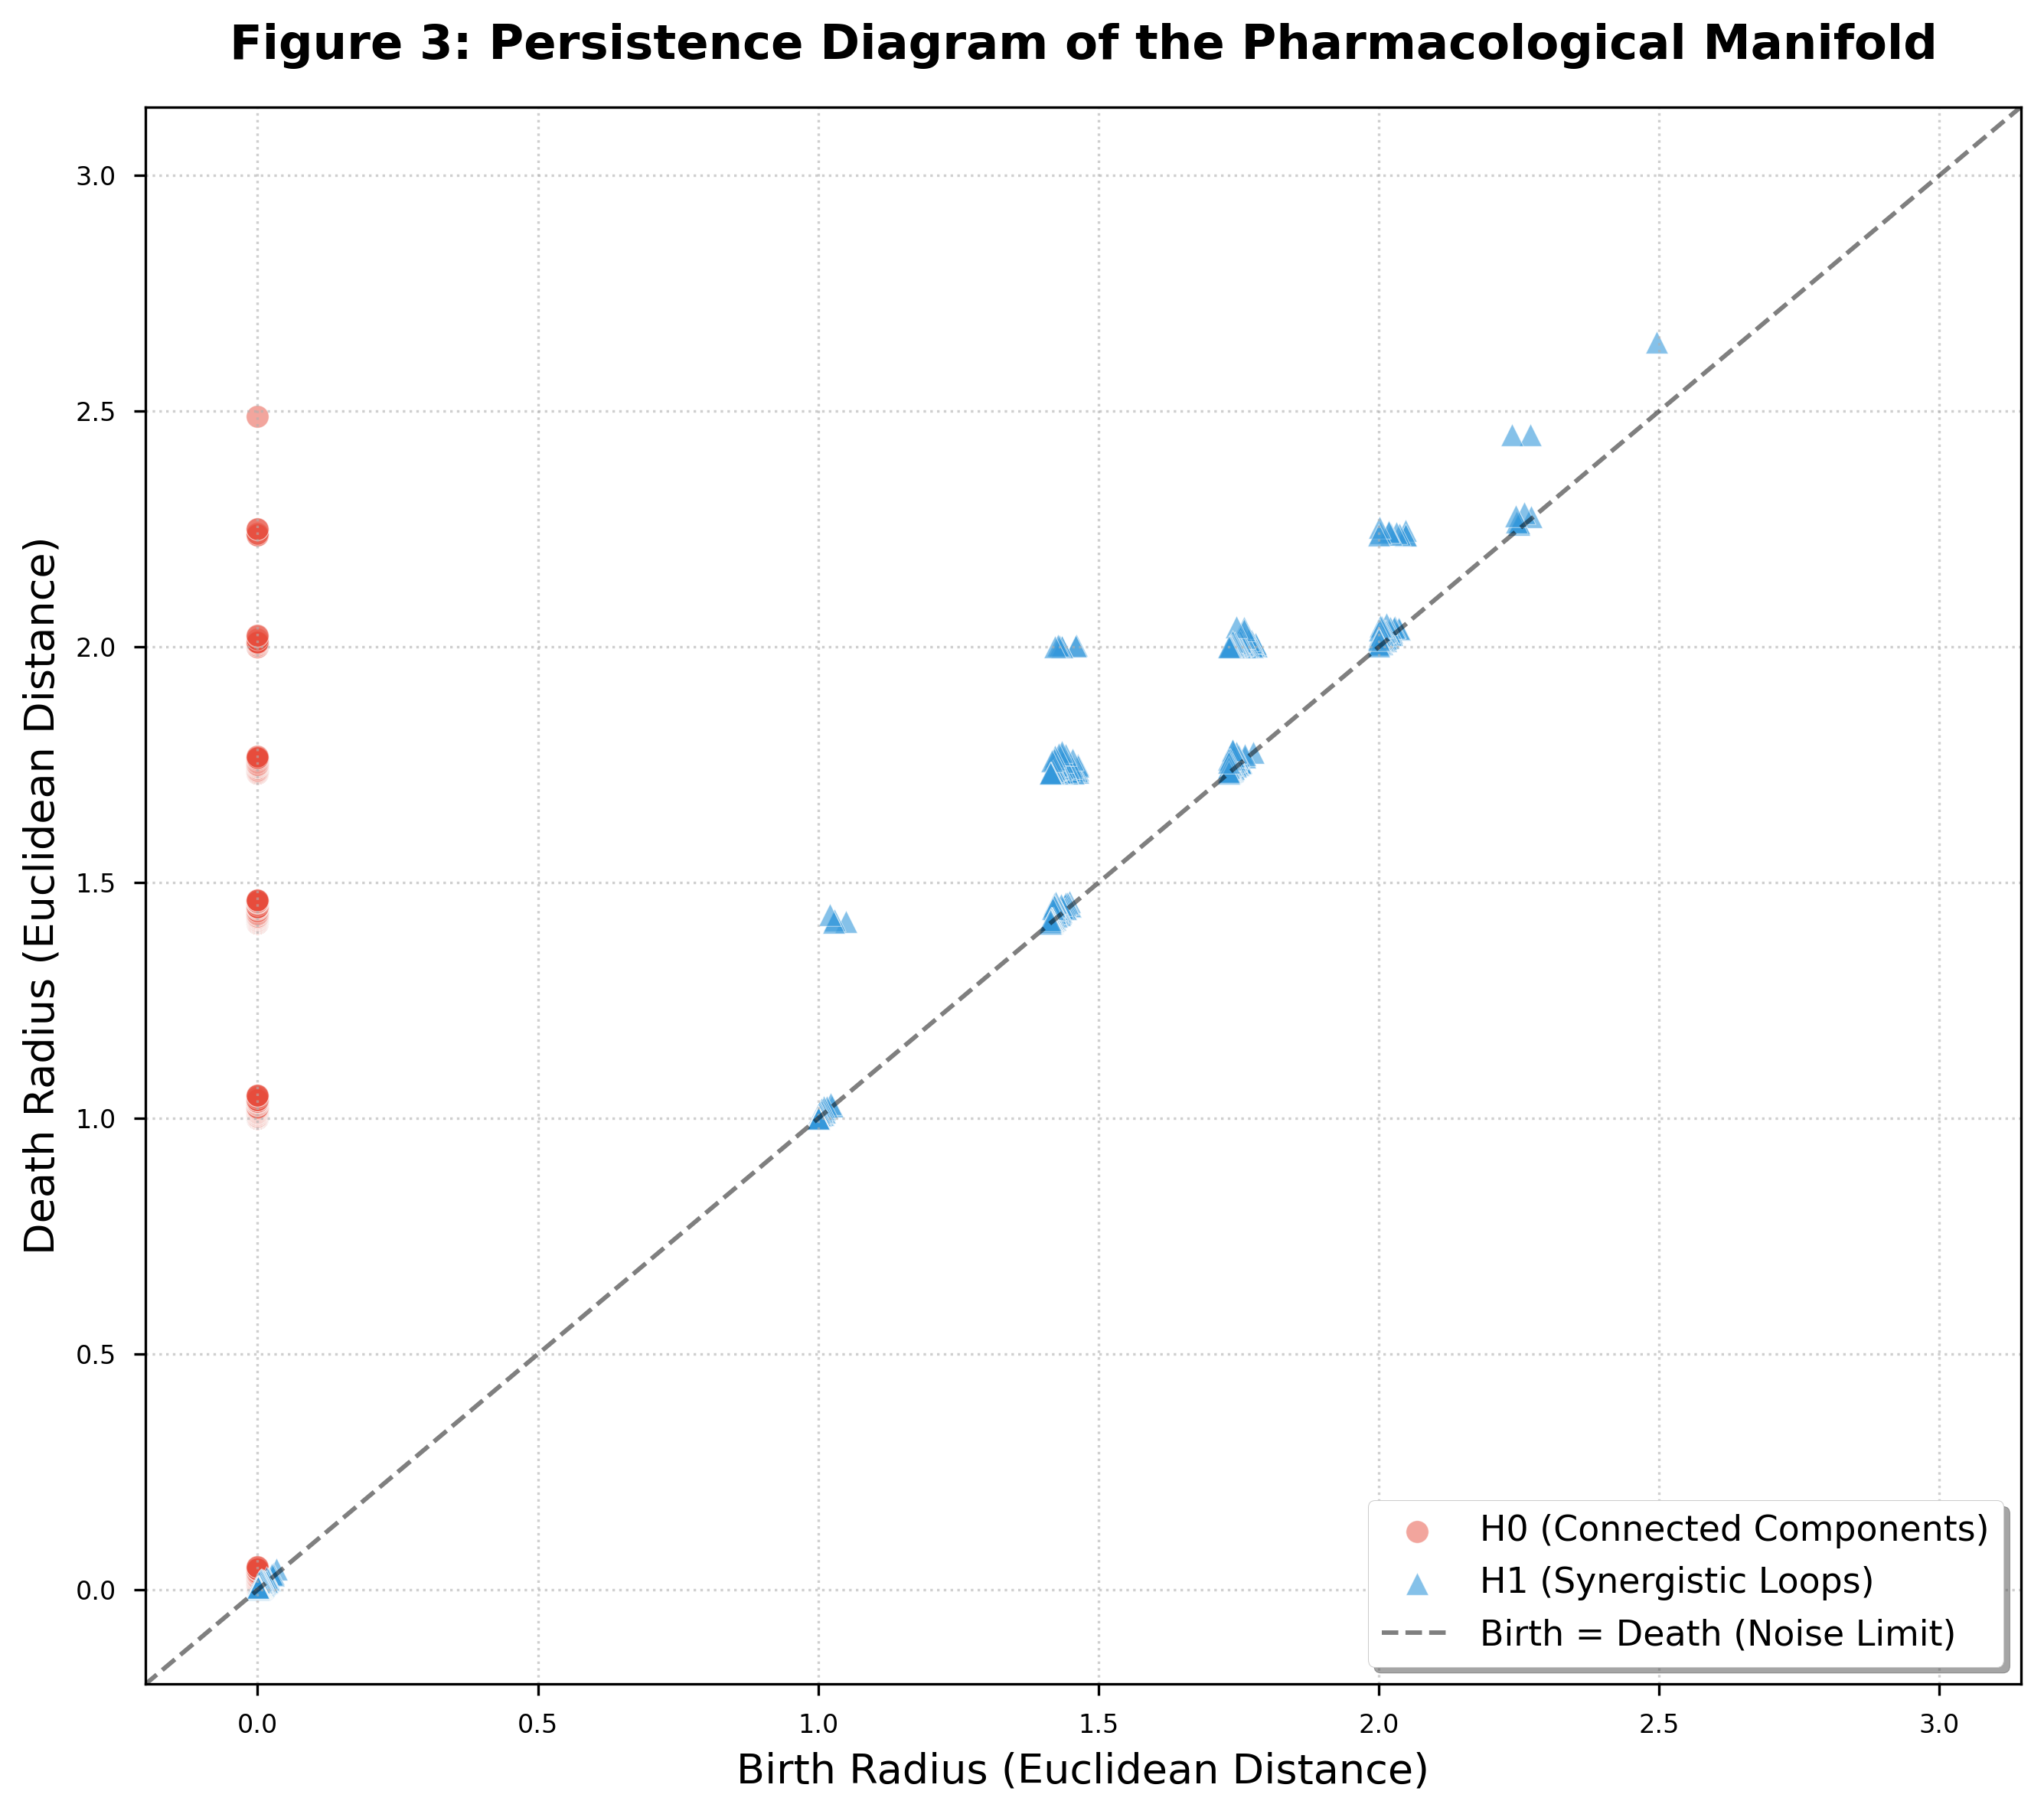


=== 4. FIGURE 4: MACROSCOPIC BETTI CURVES ===


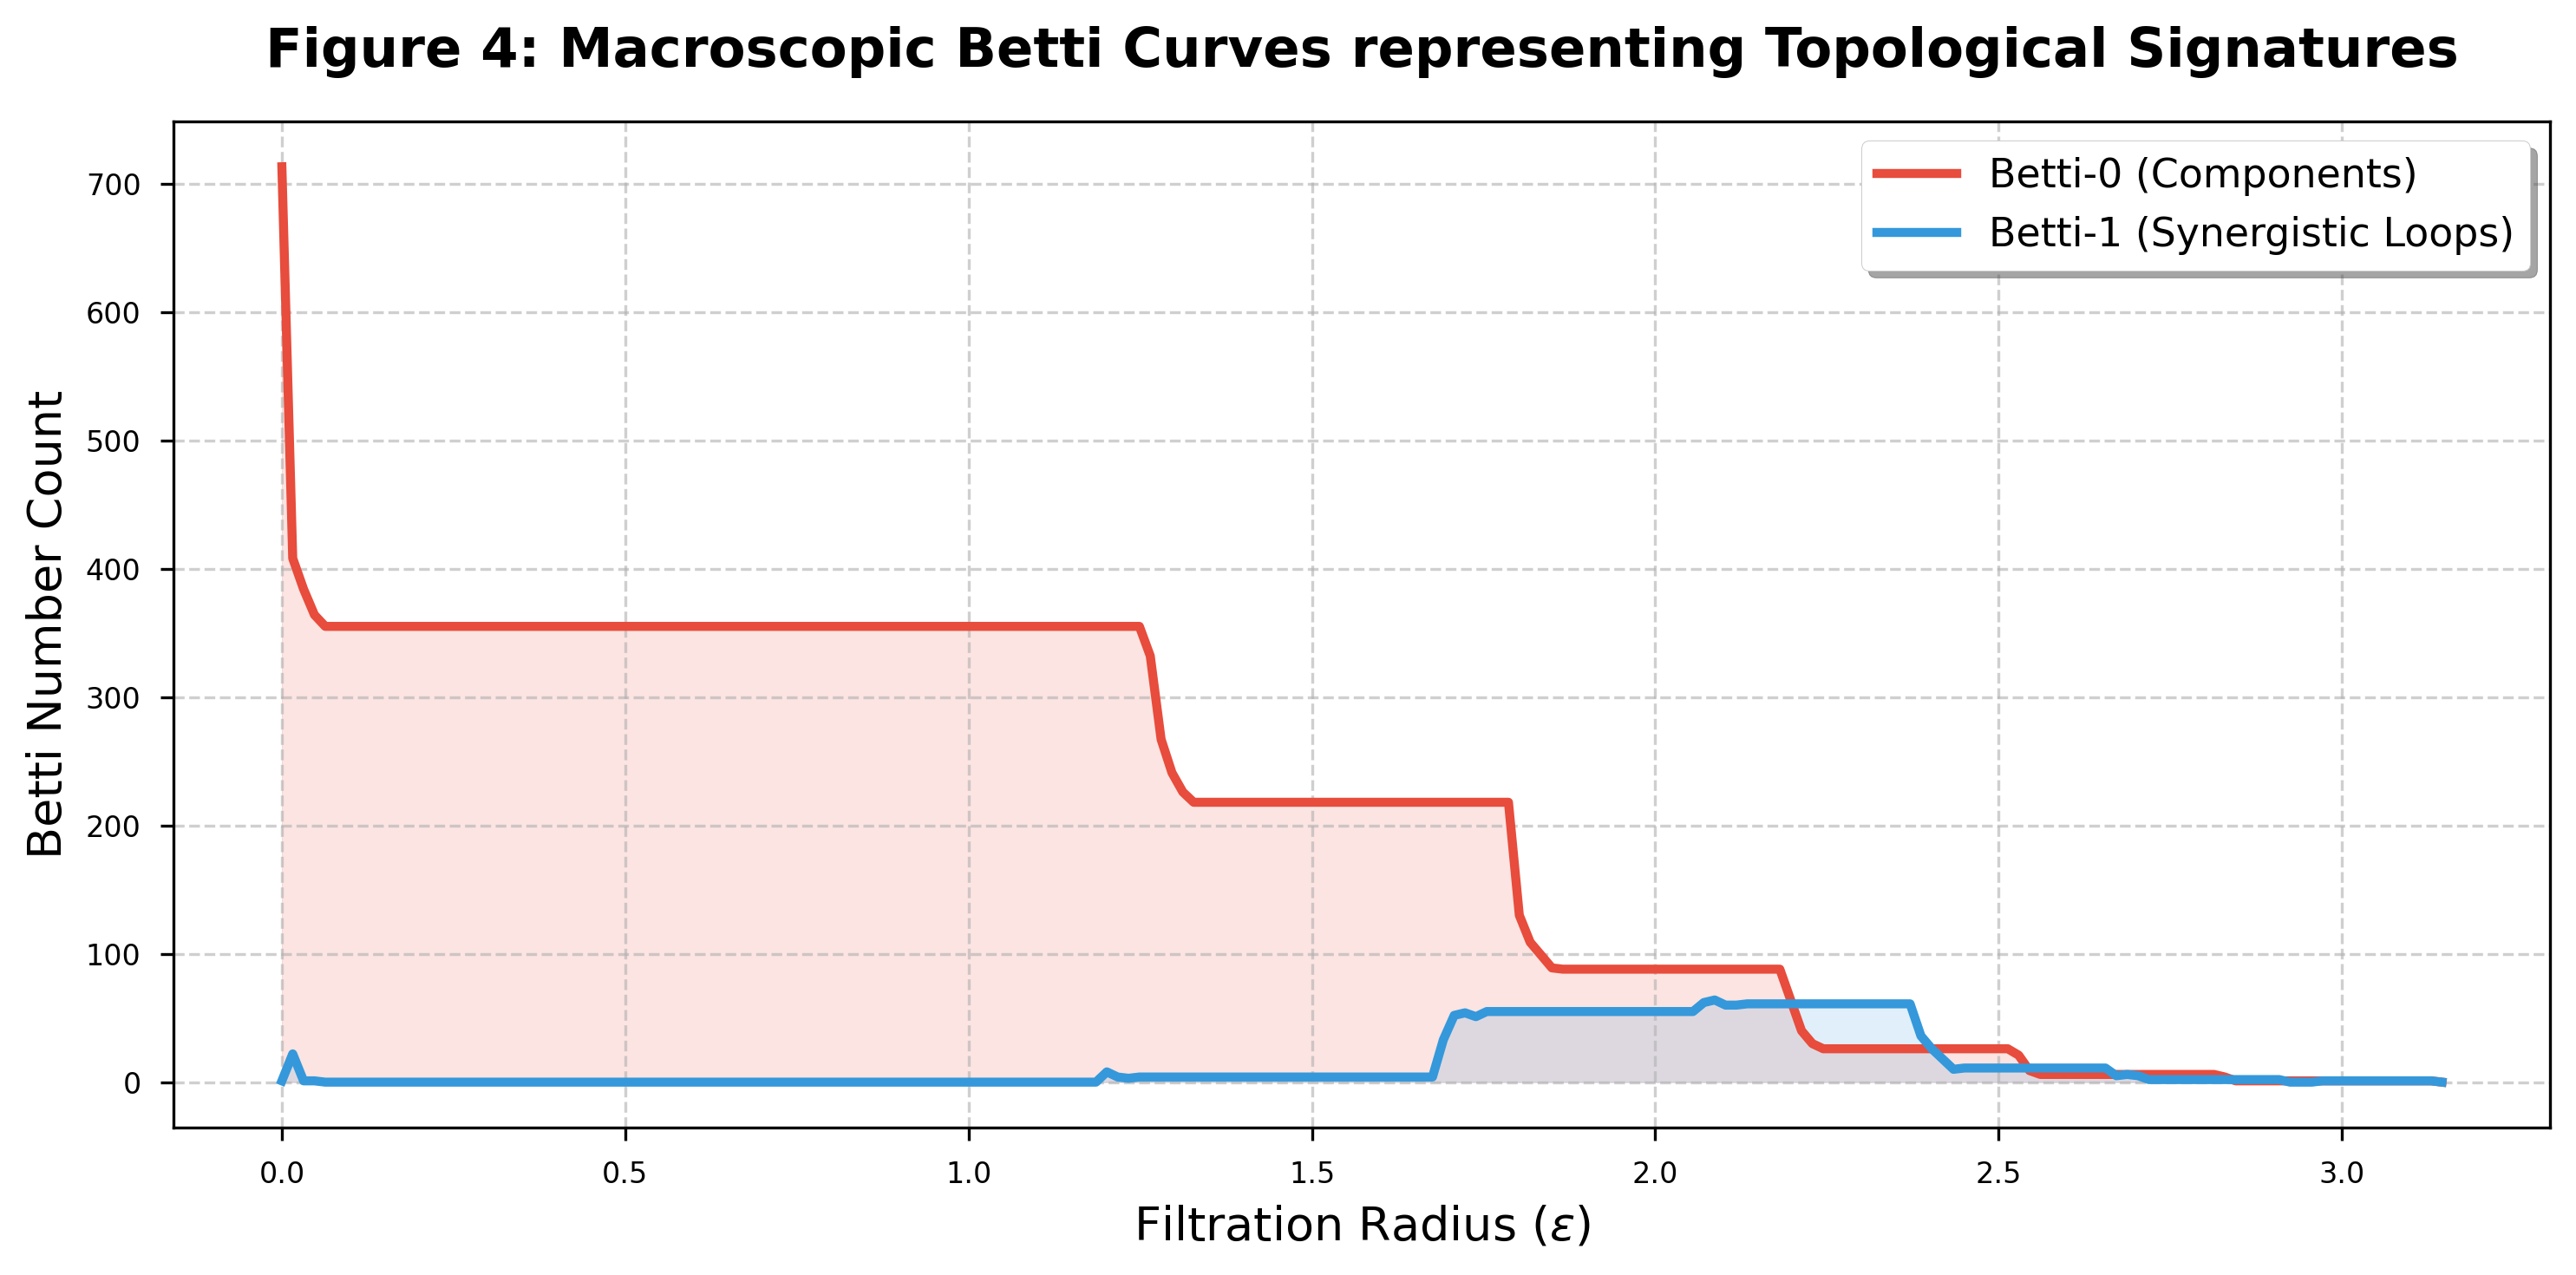


=== 5. EXPORT PROCESSED BETTI TENSORS (JSON) ===
Successfully generated 'processed_betti_tensors.json' for the Web Frontend!
All tasks complete. Please download the PNGs and the JSON file.


In [1]:
# =====================================================================
# 02_TDA_Betti_Curves.ipynb
# Phase 2: Pharmacological Euclidean Manifold, TDA, and JSON Export
# =====================================================================
!pip install numpy==1.26.4 scikit-learn==1.3.2 giotto-tda --force-reinstall
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import pairwise_distances
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import BettiCurve
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')

print("=== 1. CONSTRUCT PHARMACOLOGICAL FEATURE SPACE ===")
if not os.path.exists('curated_tm_features.pkl'):
    raise FileNotFoundError("Please run '01_Data_Curation_KG.ipynb' first to generate 'curated_tm_features.pkl'.")

df = pd.read_pickle('curated_tm_features.pkl')

# Vectorize features into a binary multidimensional space
mlb = MultiLabelBinarizer()
X_base = mlb.fit_transform(df['All_Properties'])
print(f"Pharmacological Feature Space constructed: {X_base.shape[1]} dimensions.")

# Compute Euclidean Distance Matrix
print("Computing Euclidean Distance Matrix with micro-jitter...")
dist_matrix = pairwise_distances(X_base, metric='euclidean')

# Add micro-jitter to prevent degenerate simplices (TDA best practice)
np.random.seed(42)
dist_matrix += np.random.uniform(0, 0.05, dist_matrix.shape)
np.fill_diagonal(dist_matrix, 0)

# =====================================================================
print("\n=== 2. TDA COMPUTATION ===")
vr = VietorisRipsPersistence(metric='precomputed', homology_dimensions=[0, 1])
diagrams = vr.fit_transform([dist_matrix])
diagram = diagrams[0]

# =====================================================================
print("\n=== 3. FIGURE 3: PERSISTENCE DIAGRAM ===")
plt.figure(figsize=(9, 8), dpi=300)

h0 = diagram[diagram[:, 2] == 0]
h1 = diagram[diagram[:, 2] == 1]

h0_finite = h0[h0[:, 1] != np.inf]
max_val = np.max(diagram[diagram[:, 1] != np.inf, 1]) + 0.5 if len(h0_finite) > 0 else 5.0

plt.scatter(h0_finite[:, 0], h0_finite[:, 1], c='#e74c3c', marker='o', s=50, alpha=0.5, edgecolors='white', label='H0 (Connected Components)')
plt.scatter(h1[:, 0], h1[:, 1], c='#3498db', marker='^', s=50, alpha=0.6, edgecolors='white', label='H1 (Synergistic Loops)')

plt.plot([-0.5, max_val+0.5], [-0.5, max_val+0.5], 'k--', alpha=0.5, label='Birth = Death (Noise Limit)')
plt.xlim(-0.2, max_val)
plt.ylim(-0.2, max_val)

plt.title("Figure 3: Persistence Diagram of the Pharmacological Manifold", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Birth Radius (Euclidean Distance)", fontsize=13)
plt.ylabel("Death Radius (Euclidean Distance)", fontsize=13)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("Fig3_Persistence_Diagram_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
print("\n=== 4. FIGURE 4: MACROSCOPIC BETTI CURVES ===")
N_BINS = 200
bc = BettiCurve(n_bins=N_BINS)
betti_curves = bc.fit_transform(diagrams)

betti_0 = betti_curves[0][0]
betti_1 = betti_curves[0][1]
x_axis = np.linspace(0, max_val, N_BINS)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(x_axis, betti_0, color='#e74c3c', linewidth=2.5, label='Betti-0 (Components)')
plt.plot(x_axis, betti_1, color='#3498db', linewidth=2.5, label='Betti-1 (Synergistic Loops)')
plt.fill_between(x_axis, betti_0, alpha=0.15, color='#e74c3c')
plt.fill_between(x_axis, betti_1, alpha=0.15, color='#3498db')

plt.title("Figure 4: Macroscopic Betti Curves representing Topological Signatures", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Filtration Radius ($\\epsilon$)", fontsize=13)
plt.ylabel("Betti Number Count", fontsize=13)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Fig4_Betti_Curve_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
print("\n=== 5. EXPORT PROCESSED BETTI TENSORS (JSON) ===")
# Format data for Web App consumption
betti_data = {
    "metadata": {
        "description": "Pre-computed Betti Tensors for Vi-TCM Explorer AI Engine",
        "filtration_metric": "Euclidean Distance",
        "feature_dimensions": int(X_base.shape[1]),
        "n_bins": N_BINS,
        "max_radius": float(max_val),
        "total_h1_loops": int(len(h1))
    },
    "core_network": {
        "x_axis_radii": x_axis.tolist(),
        "betti_0": betti_0.tolist(),
        "betti_1": betti_1.tolist()
    }
}

json_filename = 'processed_betti_tensors.json'
with open(json_filename, 'w', encoding='utf-8') as f:
    json.dump(betti_data, f, ensure_ascii=False, indent=4)

print(f"Successfully generated '{json_filename}' for the Web Frontend!")
print("All tasks complete. Please download the PNGs and the JSON file.")